In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from classification_training_reporter import TrainingReporter
from models.classification_lr_model import CustomLogisticRegressionModel, build_model_from_grid_params
from classification_dataset_preprocessing import make_label_pipeline, \
    make_training_pipeline, make_relative_delta_pipeline, make_delta_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Odczyt datasetu

In [2]:
df = pd.read_csv(os.path.join("../data", "ortodoncja.csv"))

# Przerobienie danych na opisujące zmianę (procentową) między wiekiem 9 a 12 lat

In [3]:
pipeline = make_relative_delta_pipeline()
df = pipeline.fit_transform(df)

# Podział danych na zbiór treningowy i testowy

In [4]:
pipeline = make_label_pipeline()
df_processed = pipeline.fit_transform(df)
label_encoder = pipeline.named_steps["encode_labels"].encoder

X = df_processed.drop(columns=["growth direction"])
y = df_processed["growth direction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tpipeline = make_training_pipeline()
X_train, y_train = tpipeline.fit_resample(X_train,y_train)
X_test = tpipeline[:1].fit_transform(X_test)

# Inicjalizacja reportera do treningów

In [5]:
model = CustomLogisticRegressionModel()
reporter = TrainingReporter(model, X_train, X_test, y_train, y_test)

# Pierwszy trening

In [6]:
reporter.train()

Start training...
Training finished!
Train Accuracy: 0.6481  |  Test Accuracy: 0.4000
Train F1:       0.6308  |  Test F1:       0.4260
Train AUROC:    0.7901  |  Test AUROC:    0.4939
---------------------------------------------------


# Cross walidacja

In [7]:
reporter.run_cross_validation(cv=10)

Start cross validation...
Fold 0:
  Train Accuracy: 0.6461  |  Val Accuracy: 0.7167
  Train F1:       0.6297  |  Val F1:       0.7022
---------------------------------------------------
Fold 1:
  Train Accuracy: 0.6479  |  Val Accuracy: 0.6667
  Train F1:       0.6314  |  Val F1:       0.6505
---------------------------------------------------
Fold 2:
  Train Accuracy: 0.6536  |  Val Accuracy: 0.5500
  Train F1:       0.6376  |  Val F1:       0.5359
---------------------------------------------------
Fold 3:
  Train Accuracy: 0.6479  |  Val Accuracy: 0.5500
  Train F1:       0.6310  |  Val F1:       0.5276
---------------------------------------------------
Fold 4:
  Train Accuracy: 0.6449  |  Val Accuracy: 0.5424
  Train F1:       0.6291  |  Val F1:       0.4990
---------------------------------------------------
Fold 5:
  Train Accuracy: 0.6542  |  Val Accuracy: 0.6271
  Train F1:       0.6384  |  Val F1:       0.6110
---------------------------------------------------
Fold 6:
  Trai

# Randomized grid search

In [8]:
random_grid = reporter.run_randomized_search_lr(cv=5)

Start randomized grid search for Logistic Regression...
Randomized search finished!
Best params: {'l1_ratio': np.float64(1.0), 'C': 1.0}
Best F1 score: 0.6007421797735342
---------------------------------------------------


# Kroswalidacja po dostosowaniu hiperparametrów za pomocą Randomized Grid Search

In [9]:
model_RGS = build_model_from_grid_params(random_grid.best_params_)
reporter_RGS = TrainingReporter(model_RGS, X_train, X_test, y_train, y_test)
reporter_RGS.run_cross_validation(cv=10)

Start cross validation...
Fold 0:
  Train Accuracy: 0.6498  |  Val Accuracy: 0.7000
  Train F1:       0.6340  |  Val F1:       0.6823
---------------------------------------------------
Fold 1:
  Train Accuracy: 0.6479  |  Val Accuracy: 0.6833
  Train F1:       0.6312  |  Val F1:       0.6662
---------------------------------------------------
Fold 2:
  Train Accuracy: 0.6554  |  Val Accuracy: 0.5500
  Train F1:       0.6388  |  Val F1:       0.5336
---------------------------------------------------
Fold 3:
  Train Accuracy: 0.6461  |  Val Accuracy: 0.5667
  Train F1:       0.6283  |  Val F1:       0.5433
---------------------------------------------------
Fold 4:
  Train Accuracy: 0.6411  |  Val Accuracy: 0.5424
  Train F1:       0.6250  |  Val F1:       0.4990
---------------------------------------------------
Fold 5:
  Train Accuracy: 0.6486  |  Val Accuracy: 0.6441
  Train F1:       0.6322  |  Val F1:       0.6292
---------------------------------------------------
Fold 6:
  Trai

## Wyniki mniej zadowalające niż na nieprzetworzonym datasecie

# Test

In [10]:
model = reporter_RGS.model
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

## Metryki

In [11]:
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test, average='weighted')
test_recall = recall_score(y_test, y_pred_test, average=None)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
cm = confusion_matrix(y_test, y_pred_test)
class_names = label_encoder.inverse_transform(range(len(label_encoder.classes_)))

## Wyniki statystyczne

In [12]:
print("\n" + "="*50)
print("TEST RESULTS")
print("="*50)
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test F1 Score:  {test_f1:.4f}")
print("Test Recall:")
for i, recall in enumerate(test_recall):
    print(f"    {class_names[i]}: {recall:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_test, target_names=class_names))


TEST RESULTS
Test Accuracy:  0.3556
Test Precision: 0.4176
Test F1 Score:  0.3772
Test Recall:
    horizontal: 0.3056
    normal: 0.3958
    vertical: 0.3333

Detailed Classification Report:
              precision    recall  f1-score   support

  horizontal       0.32      0.31      0.31        36
      normal       0.53      0.40      0.45        48
    vertical       0.10      0.33      0.15         6

    accuracy                           0.36        90
   macro avg       0.32      0.34      0.31        90
weighted avg       0.42      0.36      0.38        90



## Confusion matrix

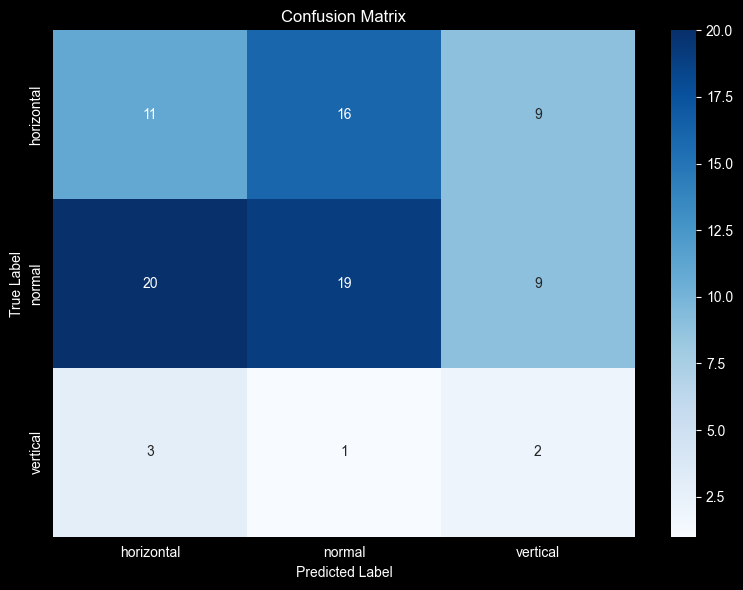

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## Porównanie kroswalidacji i testu

In [14]:
cv_f1 = random_grid.best_score_
print("\n" + "="*50)
print("CV vs TEST COMPARISON")
print("="*50)
print(f"CV F1 score:    {cv_f1:.4f}")
print(f"Test F1 score:  {test_f1:.4f}")
print(f"Gap:            {(cv_f1 - test_f1):.4f}")


CV vs TEST COMPARISON
CV F1 score:    0.6007
Test F1 score:  0.3772
Gap:            0.2235


# Robienie modelu klasyfikujacego na podstawie samych różnic między wiekiem 9 a 12 lat nie wydaje się dobrą drogą